In [ ]:
import numpy as np
import pandas as pd


In [ ]:
import pandas as pd
df = pd.read_csv("laptops.csv")
print(df.head())

                                              Laptop Status   Brand  \
0  ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core...    New    Asus   
1  Alurin Go Start Intel Celeron N4020/8GB/256GB ...    New  Alurin   
2  ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core...    New    Asus   
3  MSI Katana GF66 12UC-082XES Intel Core i7-1270...    New     MSI   
4  HP 15S-FQ5085NS Intel Core i5-1235U/16GB/512GB...    New      HP   

        Model            CPU  RAM  Storage Storage type       GPU  Screen  \
0  ExpertBook  Intel Core i5    8      512          SSD       NaN    15.6   
1          Go  Intel Celeron    8      256          SSD       NaN    15.6   
2  ExpertBook  Intel Core i3    8      256          SSD       NaN    15.6   
3      Katana  Intel Core i7   16     1000          SSD  RTX 3050    15.6   
4         15S  Intel Core i5   16      512          SSD       NaN    15.6   

  Touch  Final Price  
0    No      1009.00  
1    No       299.00  
2    No       789.00  
3    No      1199.

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
df = df[['ram', 'storage', 'screen', 'final_price']]
df.head()

,ram,storage,screen,final_price
0,8,512,15.6,1009.00
1,8,256,15.6,299.00
2,8,256,15.6,789.00
3,16,1000,15.6,1199.00
4,16,512,15.6,669.01


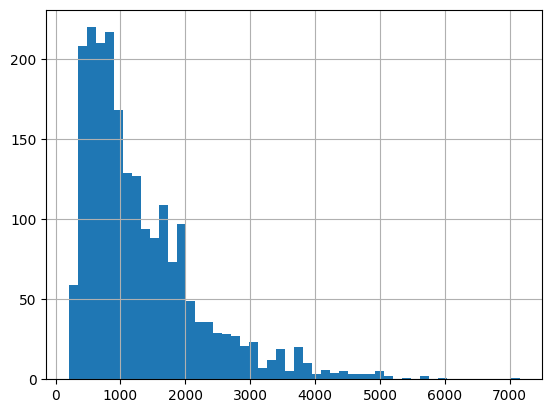

In [ ]:
df['final_price'].hist(bins=50)
plt.show()

In [ ]:
df.isnull().sum()

,0
ram,0
storage,0
screen,4
final_price,0


In [ ]:
df['ram'].median()

16.0

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)
len(df_train), len(df_val), len(df_test)

(1296, 432, 432)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
train_0 = df_train.fillna(0)
val_0 = df_val.fillna(0)

X_train = train_0[['ram', 'storage', 'screen']]
y_train = train_0['final_price']

X_val = val_0[['ram', 'storage', 'screen']]
y_val = val_0['final_price']

pred = model.predict(X_val)

rmse_0 = round(np.sqrt(mean_squared_error(y_val, pred)), 2)
rmse_0

np.float64(609.42)

In [ ]:
mean_storage = df_train['storage'].mean()
train_mean = df_train.fillna(mean_storage)
val_mean = df_val.fillna(mean_storage)
model = LinearRegression()
model.fit(train_mean[['ram','storage','screen']], y_train)
pred = model.predict(val_mean[['ram','storage','screen']])
rmse_0 = round(np.sqrt(mean_squared_error(y_val, pred)), 2)
rmse_0

np.float64(612.29)

In [ ]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in r_values:
    model = Ridge(alpha=r)
    model.fit(train_0[['ram','storage','screen']], y_train)
    pred = model.predict(val_0[['ram','storage','screen']])
rmse_0 = round(np.sqrt(mean_squared_error(y_val, pred)), 2)
print("r =", r, "RMSE =", rmse_0)

r = 100 RMSE = 609.53


In [ ]:
scores = []
for seed in range(10):
    train, temp = train_test_split(df, test_size=0.4, random_state=seed)
    val, _ = train_test_split(temp, test_size=0.5, random_state=seed)
    train = train.fillna(0)
    val = val.fillna(0)
    model = LinearRegression()
    model.fit(train[['ram','storage','screen']], train['final_price'])
    pred = model.predict(val[['ram','storage','screen']])
    rmse = np.sqrt(mean_squared_error(val['final_price'], pred))
    scores.append(rmse)
round(np.std(scores), 3)

np.float64(35.825)

In [ ]:
train, temp = train_test_split(df, test_size=0.4, random_state=9)
val, test = train_test_split(temp, test_size=0.5, random_state=9)
full_train = pd.concat([train, val]).fillna(0)
test = test.fillna(0)
model = Ridge(alpha=0.001)
model.fit(full_train[['ram','storage','screen']], full_train['final_price'])
pred = model.predict(test[['ram','storage','screen']])
round(np.sqrt(mean_squared_error(test['final_price'], pred)), 2)

np.float64(602.43)